In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [108]:
import openpyxl
# Load all stations' Excel files into a dict
folder = 'heat_index_files'  # path to your data folder

filenames = {
    'KAVL': 'KAVL-heatindex-1971-2021.xlsx',
    'KGSO': 'KGSO-heatindex-1971-2021.xlsx',
    'KHSE': 'KHSE-heatindex-1971-2021.xlsx',
    'KILM': 'KILM-heatindex-1971-2021.xlsx',
    'KCLT': 'KLCT-heatindex-1971-2021.xlsx',
    'KRDU': 'KRDU-heat-index-1971-2021.xlsx',
}

dfs = {}

for station, file in filenames.items():
    path = os.path.join(folder, file)
    df = pd.read_excel(path)
    df['station'] = station
    dfs[station] = df

In [109]:
print(df.columns)
print(len(df.columns))  # Check the number of columns

Index(['date', 'heatindexmax2m', 'heatindexmin2m', 'heatindexavg2m',
       'station'],
      dtype='object')
5


In [110]:

# Combine all dataframes into one
all_data = pd.concat(dfs.values(), ignore_index=True)
all_data.head()


,datetime,heatindexmax2m,heatindexmin2m,station,date,heatindexavg2m
0,1971-01-01,35.8,20.9,KAVL,NaN,NaN
1,1971-01-02,46.8,14.7,KAVL,NaN,NaN
2,1971-01-03,43.0,20.4,KAVL,NaN,NaN
3,1971-01-04,56.0,38.2,KAVL,NaN,NaN
4,1971-01-05,51.6,26.9,KAVL,NaN,NaN


In [111]:
# df['heatindexmin2m'] = pd.to_numeric(df['heatindexmin2m'], errors='coerce')


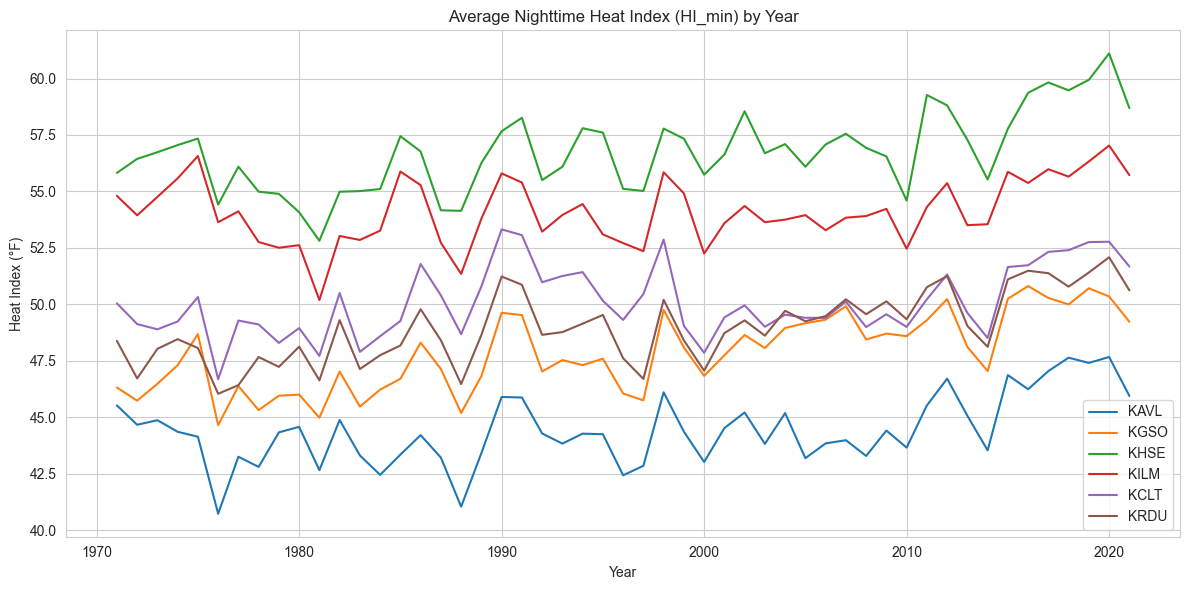

In [112]:
# Plot average HI_min per year by station
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

for station in filenames.keys():
    df = dfs[station].copy()  # Add .copy() here
    
    # Ensure 'heatindexmin2m' is numeric
    df['heatindexmin2m'] = pd.to_numeric(df['heatindexmin2m'], errors='coerce')
    
    # Handle missing values
    df = df.dropna(subset=['heatindexmin2m'])
    
    # Ensure 'datetime' is a datetime column
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    elif 'date' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'])
    else:
        raise KeyError("The dataframe does not contain a 'datetime' or 'date' column.")
    
    # Group by year
    df['year'] = df['datetime'].dt.year  # Remove .loc[:, ...] since df is now a copy
    yearly = df.groupby('year')['heatindexmin2m'].mean()
    
    # Plot the data
    plt.plot(yearly.index, yearly.values, label=station)

plt.title('Average Nighttime Heat Index (HI_min) by Year')
plt.ylabel('Heat Index (°F)')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

In [113]:
df.columns

Index(['date', 'heatindexmax2m', 'heatindexmin2m', 'heatindexavg2m', 'station',
       'datetime', 'year'],
      dtype='object')

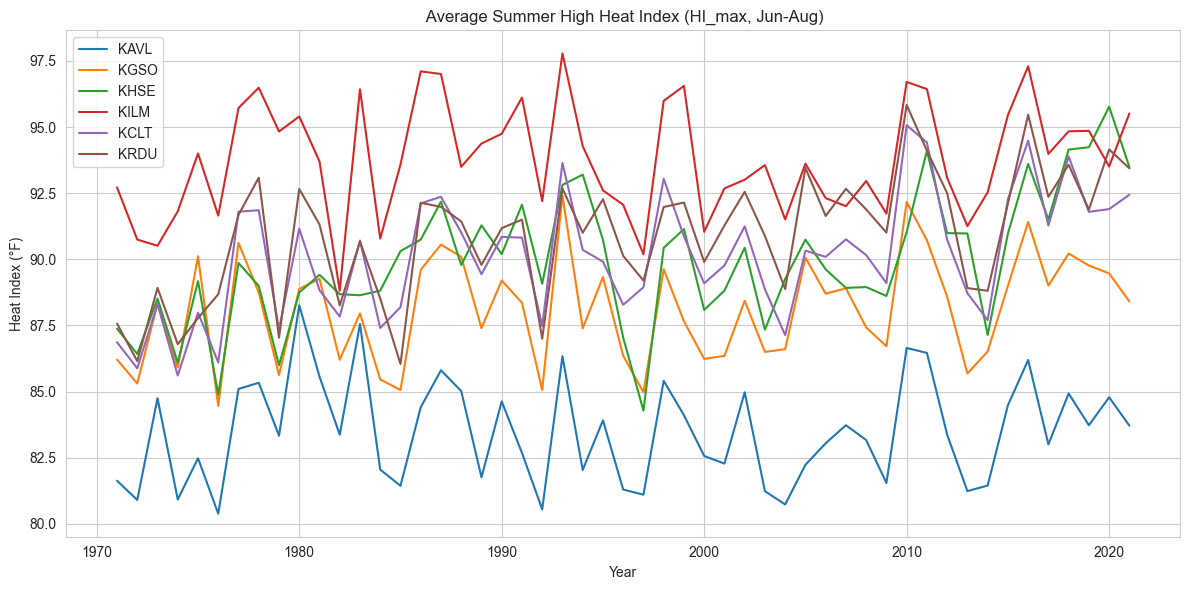

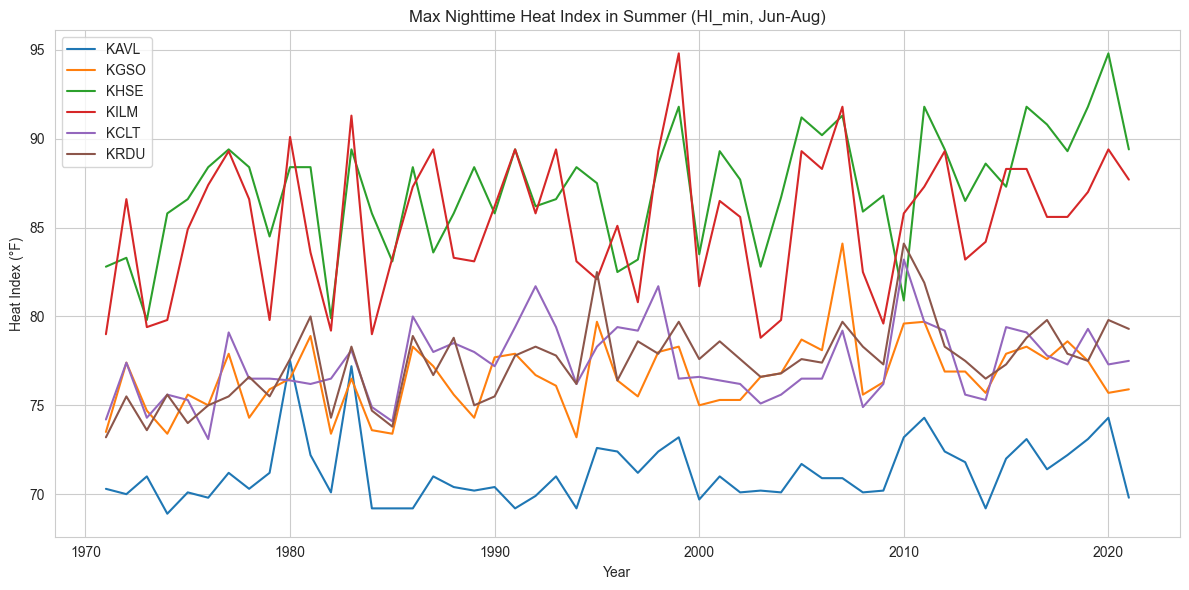

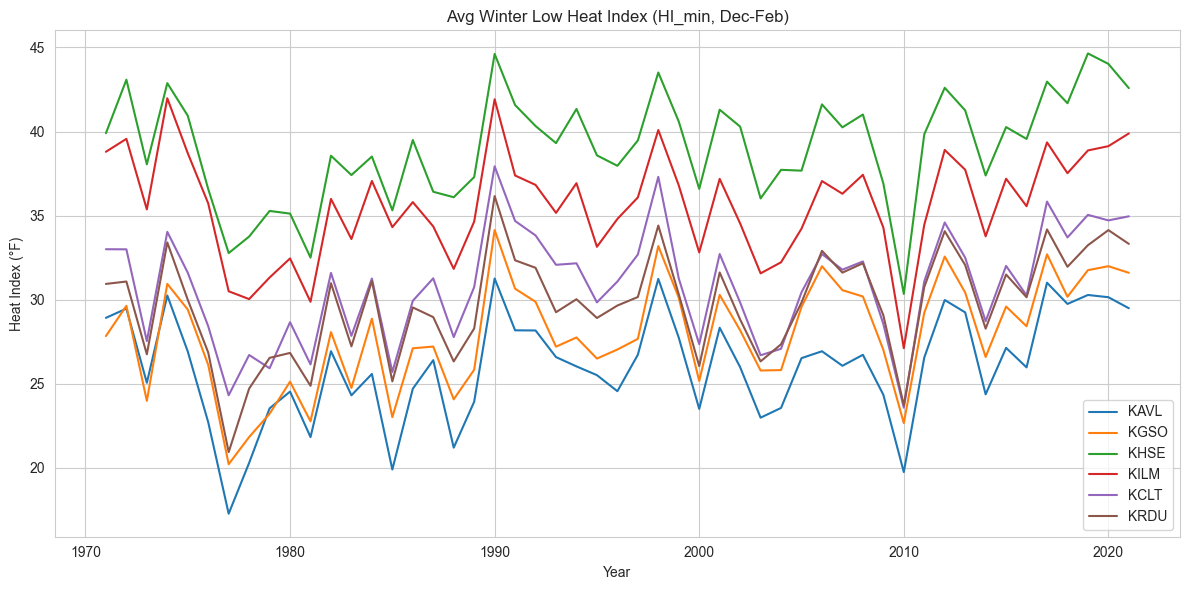

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style('whitegrid')

folder = 'heat_index_files'

filenames = {
    'KAVL': 'KAVL-heatindex-1971-2021.xlsx',
    'KGSO': 'KGSO-heatindex-1971-2021.xlsx',
    'KHSE': 'KHSE-heatindex-1971-2021.xlsx',
    'KILM': 'KILM-heatindex-1971-2021.xlsx',
    'KCLT': 'KLCT-heatindex-1971-2021.xlsx',
    'KRDU': 'KRDU-heat-index-1971-2021.xlsx',
}

dfs = {}
for station, file in filenames.items():
    path = os.path.join(folder, file)
    df = pd.read_excel(path)
    df['station'] = station
    
    # Convert heat index columns to numeric (only if they exist)
    if 'heatindexmax2m' in df.columns:
        df['heatindexmax2m'] = pd.to_numeric(df['heatindexmax2m'], errors='coerce')
    if 'heatindexmin2m' in df.columns:
        df['heatindexmin2m'] = pd.to_numeric(df['heatindexmin2m'], errors='coerce')
    if 'heatindexavg2m' in df.columns:
        df['heatindexavg2m'] = pd.to_numeric(df['heatindexavg2m'], errors='coerce')
    
    # Handle different possible date column names
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
    elif 'date' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'])
    else:
        print(f"Station {station} columns: {df.columns.tolist()}")
        raise KeyError(f"No date/datetime column found in {file}")
    
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    dfs[station] = df

# Combine all stations
all_data = pd.concat(dfs.values(), ignore_index=True)

# 1. ☀️ Summer High Temp Trends (HI_max)
plt.figure(figsize=(12, 6))
for station in filenames.keys():
    summer = dfs[station][dfs[station]['month'].isin([6, 7, 8])]
    summer = summer.dropna(subset=['heatindexmax2m'])
    hi_max_avg = summer.groupby('year')['heatindexmax2m'].mean()
    plt.plot(hi_max_avg.index, hi_max_avg.values, label=station)

plt.title(' Average Summer High Heat Index (HI_max, Jun-Aug)')
plt.xlabel('Year')
plt.ylabel('Heat Index (°F)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Summer Maximum Nighttime Lows (HI_min)
plt.figure(figsize=(12, 6))
for station in filenames.keys():
    summer = dfs[station][dfs[station]['month'].isin([6, 7, 8])]
    summer = summer.dropna(subset=['heatindexmin2m'])
    max_lows = summer.groupby('year')['heatindexmin2m'].max()
    plt.plot(max_lows.index, max_lows.values, label=station)

plt.title('Max Nighttime Heat Index in Summer (HI_min, Jun-Aug)')
plt.xlabel('Year')
plt.ylabel('Heat Index (°F)')
plt.legend()
plt.tight_layout()
plt.show()

# 3. ❄️ Winter Low Temp Trends (HI_min, Dec–Feb)
plt.figure(figsize=(12, 6))
for station in filenames.keys():
    df = dfs[station]
    winter = df[df['month'].isin([12, 1, 2])]
    winter = winter.dropna(subset=['heatindexmin2m'])
    winter_avg = winter.groupby('year')['heatindexmin2m'].mean()
    plt.plot(winter_avg.index, winter_avg.values, label=station)

plt.title('Avg Winter Low Heat Index (HI_min, Dec-Feb)')
plt.xlabel('Year')
plt.ylabel('Heat Index (°F)')
plt.legend()
plt.tight_layout()
plt.show()